In [ ]:
#Are there statistically significant effects for streamer gender, age, and genre on the expression of the 12 emotions 
#in remote-containing messages? 
# Logistic Regression per emote, with streamer level clustered SE

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
df = pd.read_csv("/Users/inecuypers/Documents/DTA thesis/finals/df_sentiment_emotion_final.csv", index_col=0)
df.head(1)

,id,streamer,message,emotes,gender,age,genre,unique_emotes,total_emotes,sentiment,...,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,6b9fd713-82dc-4f76-90b3-a7d2f006e1ac,annacramling,Gg CoolCat,CoolCat,female,genz,nongaming,1,1,2,...,False,False,False,True,False,True,False,False,False,True


In [2]:
emotion_cols = [
    "anger", "anticipation", "disgust", "fear", "joy", "love",
    "optimism", "pessimism", "sadness", "surprise", "trust"
]
df_rq4 = df.copy()

In [3]:
# ensure binary 0/1
for emo in emotion_cols:
    df_rq4[emo] = df_rq4[emo].astype(int)

In [8]:
import io
import matplotlib.pyplot as plt
import seaborn as sns

results_rq4 = []

for emo in emotion_cols:
    # Fit the Interaction Model
    # Using Logit because the outcome is binary (Presence)
    model = smf.logit(f"{emo} ~ gender * age * genre", data=df_rq4)

    # Cluster by streamer to account for community-level correlation
    try:
        results = model.fit(method='lbfgs', cov_type='cluster', cov_kwds={'groups': df['streamer']}, disp=0)

        print(f"\n--- Results for Emote: {emo} ---")
        print(results.summary())

        # Exporting Odds Ratios for easier interpretation
        # OR > 1 means higher likelihood of usage
        odds_ratios = np.exp(results.params)
        print(f"Odds Ratios for {emo}:\n", odds_ratios)

        if results.mle_retvals['converged']:
          # USE 'results.params', NOT 'model.params'
          for term in results.params.index:
              if term == "Intercept":
                  continue

              results_rq4.append({
                  "emotion": emo,
                  "predictor": term,
                  "coef": results.params[term],
                  "odds_ratio": np.exp(results.params[term]),
                  "p_value": results.pvalues[term]
              })

    except Exception as e:
        print(f"Model for {emo} failed to converge: {e}")

    # --- A. Save LaTeX Table ---
    html_table = results.summary().tables[1].as_html()
    res_df = pd.read_html(io.StringIO(html_table), header=0, index_col=0)[0]

    res_df.to_latex(f"table_presence_{emo}.tex", escape=False)

    # --- B. Create Marginal Effects Plot ---
    # Create prediction grid for all 8 combinations
    combos = df[['gender', 'age', 'genre']].drop_duplicates()
    combos['prob'] = results.predict(combos)

    plt.figure(figsize=(8, 6))
    sns.set_theme(style="whitegrid")
    g = sns.catplot(
        data=combos, x="gender", y="prob", hue="age",
        col="genre", kind="point", capsize=.1, height=5, aspect=0.8
    )

    g.set_axis_labels("Gender", "Predicted Probability", fontweight="bold")
    g.set_titles("{col_name}", fontweight="bold")
    g.fig.suptitle(f"Marginal Effects of Gender, Age, Genre on Presence {emo.title()}", y=1.05, fontweight="bold")
    # Remove Seaborn's legend
    g._legend.remove()
    
    # Get the handles and labels
    handles, labels = g.axes.flat[0].get_legend_handles_labels()
    
    # Save handles and labels before removing the legend
    handles = g.legend.legend_handles
    labels = [t.get_text() for t in g.legend.get_texts()]
    
    # Create a new one
    legend = g.fig.legend(
        handles,
        labels,
        title="Age",
        loc="center right",      # similar to Seaborn's default
        bbox_to_anchor=(0.98, 0.5),
        frameon=True,
        facecolor="white",
        edgecolor="lightgrey",
        shadow=True
    )
    
    # Bold text
    legend.get_title().set_fontweight("bold")
    for text in legend.get_texts():
        text.set_fontweight("bold")

    # Bold facet titles and tick labels
    for ax in g.axes.flat:
        ax.set_title(ax.get_title(), fontweight="bold")
        for label in ax.get_xticklabels():
            label.set_fontweight("bold")
        for label in ax.get_yticklabels():
            label.set_fontweight("bold")


    plt.savefig(f"plot_presence_{emo}.png", dpi=300, bbox_inches='tight')
    plt.close() # Close to free up memory during the loop

print("All models and plots completed.")


--- Results for Emote: anger ---
                           Logit Regression Results                           
Dep. Variable:                  anger   No. Observations:                 9600
Model:                          Logit   Df Residuals:                     9592
Method:                           MLE   Df Model:                            7
Date:                Sat, 15 Aug 2026   Pseudo R-squ.:                 0.03033
Time:                        14:45:00   Log-Likelihood:                -2595.0
converged:                       True   LL-Null:                       -2676.2
Covariance Type:              cluster   LLR p-value:                 1.036e-31
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                              -2.8282      0.129    -21.865      0.00

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [40]:
for emo in emotion_cols:
    # 1. Re-fit or filter for Gender x Genre
    # Note: We still use the full model to get the most accurate probabilities,
    # but we aggregate the prediction grid to just Gender and Genre.

    combos = df[['gender', 'genre', 'age']].drop_duplicates()
    combos['prob'] = results.predict(combos)

    # Aggregate (mean) across Age to isolate Gender x Genre
    plot_data = combos.groupby(['age', 'genre'])['prob'].mean().reset_index()

    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})

    # Using a pointplot to show the interaction lines clearly
    g = sns.pointplot(
        data=plot_data,
        x="age",
        y="prob",
        hue="genre",
    )

    # 3. Clean up the "UI" of the plot
    plt.title(f"Marginal Effects of Age and Genre on Presence {emo.title()}", pad=20, fontweight='bold')
    plt.xlabel("Streamer Age", fontweight='bold')
    plt.ylabel(f"Predicted Probability", fontweight='bold')

    # Move legend to a clean spot
    legend = plt.legend(
        title="Genre",
        frameon=True,
        shadow=True,
        facecolor="white"
    )
        # Bold text
    legend.get_title().set_fontweight("bold")
    for text in legend.get_texts():
        text.set_fontweight("bold")

    ax = plt.gca()
    
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    # Remove top and right spines for a modern look
    sns.despine()

    # Save
    plt.savefig(f"plot_age_genre_{emo}.png", dpi=300, bbox_inches='tight')
    plt.close()

print("Gender x Genre interaction plots generated.")

Gender x Genre interaction plots generated.


In [41]:
for emo in emotion_cols:
    # 1. Re-fit or filter for Gender x Genre
    # Note: We still use the full model to get the most accurate probabilities,
    # but we aggregate the prediction grid to just Gender and Genre.

    combos = df[['gender', 'genre', 'age']].drop_duplicates()
    combos['prob'] = results.predict(combos)

    # Aggregate (mean) across Age to isolate Gender x Genre
    plot_data = combos.groupby(['gender', 'age'])['prob'].mean().reset_index()

    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})

    # Using a pointplot to show the interaction lines clearly
    g = sns.pointplot(
        data=plot_data,
        x="age",
        y="prob",
        hue="gender",
    )

    # 3. Clean up the "UI" of the plot
    plt.title(f"Marginal Effects of Gender and Age on Presence {emo.title()}", pad=20, fontweight='bold')
    plt.xlabel("Streamer Age", fontweight='bold')
    plt.ylabel(f"Predicted Probability", fontweight='bold')

    # Move legend to a clean spot
    legend = plt.legend(
        title="Genre",
        frameon=True,
        shadow=True,
        facecolor="white"
    )
    # Bold text
    legend.get_title().set_fontweight("bold")
    for text in legend.get_texts():
        text.set_fontweight("bold")
    
    ax = plt.gca()
    
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")
    
    # Remove top and right spines for a modern look
    sns.despine()

    # Save
    plt.savefig(f"plot_gender_age_{emo}.png", dpi=300, bbox_inches='tight')
    plt.close()

print("Gender x Genre interaction plots generated.")

Gender x Genre interaction plots generated.


In [34]:
for emo in emotion_cols:
    # Note: We still use the full model to get the most accurate probabilities,
    # but we aggregate the prediction grid to just Gender and Genre.

    combos = df[['gender', 'genre', 'age']].drop_duplicates()
    combos['prob'] = results.predict(combos)

    # Aggregate (mean) across Age to isolate Gender x Genre
    plot_data = combos.groupby('gender')['prob'].mean().reset_index()

    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})

    # Using a pointplot to show the interaction lines clearly
    g = sns.pointplot(
        data=plot_data,
        x="gender",
        y="prob",
    )

    # 3. Clean up the "UI" of the plot
    plt.title(f"Marginal Effect of Gender on Presence {emo.title()}", pad=20, fontweight='bold')
    plt.xlabel("Streamer Gender", fontweight='bold')
    plt.ylabel(f"Predicted Probability", fontweight='bold')

    ax = plt.gca()
    
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")
    
    # Remove top and right spines for a modern look
    sns.despine()

    # Save
    plt.savefig(f"plot_gender_{emo}.png", dpi=300, bbox_inches='tight')
    plt.close()

print("interaction plots generated.")

interaction plots generated.


In [33]:
for emo in emotion_cols:
    # Note: We still use the full model to get the most accurate probabilities,
    # but we aggregate the prediction grid to just Gender and Genre.

    combos = df[['gender', 'genre', 'age']].drop_duplicates()
    combos['prob'] = results.predict(combos)

    # Aggregate (mean) across Age to isolate Gender x Genre
    plot_data = combos.groupby('age')['prob'].mean().reset_index()

    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})

    # Using a pointplot to show the interaction lines clearly
    g = sns.pointplot(
        data=plot_data,
        x="age",
        y="prob",
    )

    # 3. Clean up the "UI" of the plot
    plt.title(f"Marginal Effect of Age on Presence {emo.title()}", pad=20, fontweight='bold')
    plt.xlabel("Streamer Age", fontweight='bold')
    plt.ylabel(f"Predicted Probability", fontweight='bold')

    # Make tick labels bold
    ax = plt.gca()
    
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    # Remove top and right spines for a modern look
    sns.despine()

    # Save
    plt.savefig(f"plot_age_{emo}.png", dpi=300, bbox_inches='tight')
    plt.close()

print("interaction plots generated.")

interaction plots generated.


In [32]:
for emo in emotion_cols:
    # Note: We still use the full model to get the most accurate probabilities,
    # but we aggregate the prediction grid to just Gender and Genre.

    combos = df[['gender', 'genre', 'age']].drop_duplicates()
    combos['prob'] = results.predict(combos)

    # Aggregate (mean) across Age to isolate Gender x Genre
    plot_data = combos.groupby('genre')['prob'].mean().reset_index()

    # 2. Plotting for "Buttony" Aesthetic
    plt.figure(figsize=(10, 6))
    sns.set_context("talk") # Makes labels larger/bolder
    sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})

    # Using a pointplot to show the interaction lines clearly
    g = sns.pointplot(
        data=plot_data,
        x="genre",
        y="prob",
    )

    # 3. Clean up the "UI" of the plot
    plt.title(f"Marginal Effect of Genre on Presence {emo.title()}", pad=20, fontweight='bold')
    plt.xlabel("Stream Genre", fontweight='bold')
    plt.ylabel(f"Predicted Probability", fontweight='bold')

    # Make tick labels bold
    ax = plt.gca()
    
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    # Remove top and right spines for a modern look
    sns.despine()

    # Save
    plt.savefig(f"plot_genre_{emo}.png", dpi=300, bbox_inches='tight')
    plt.close()

print("interaction plots generated.")

interaction plots generated.


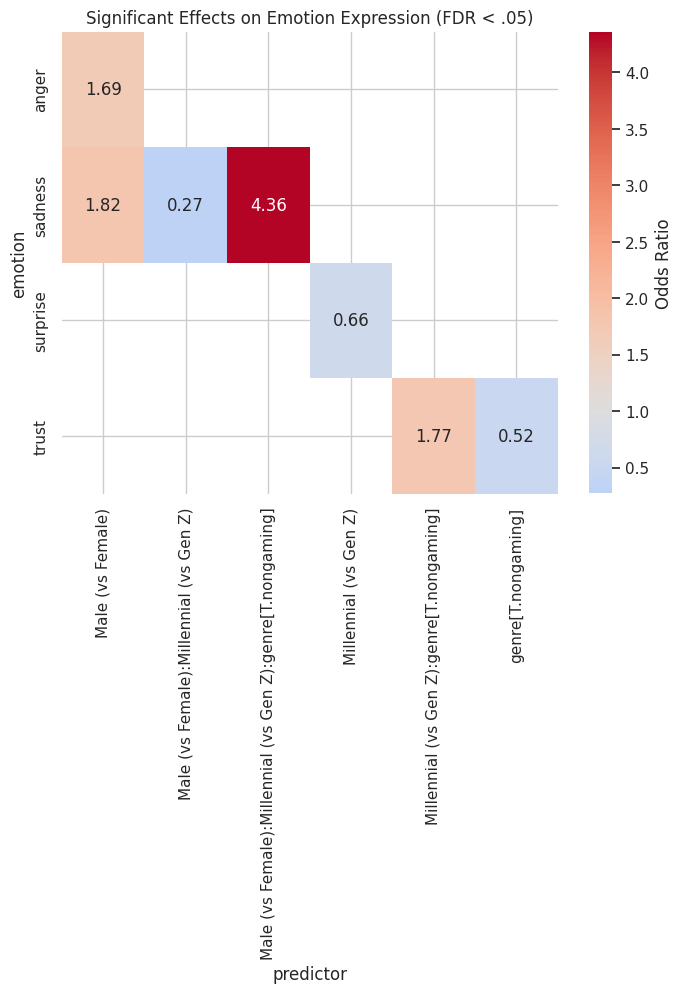

In [30]:
# significance-filtered heatmap
plot_df = pd.DataFrame(results_rq4)

plot_df["predictor"] = (
    plot_df["predictor"]
    .str.replace("gender[T.male]", "Male (vs Female)")
    .str.replace("age[T.millennial]", "Millennial (vs Gen Z)")
    .str.replace("genre[T.gaming]", "Gaming (vs Non-gaming)")
)

sig_df = plot_df[plot_df["p_value"] < 0.05]

heatmap_sig = sig_df.pivot(
    index="emotion",
    columns="predictor",
    values="odds_ratio"
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_sig,
    annot=True,
    fmt=".2f",
    center=1,
    cmap="coolwarm",
    cbar_kws={"label": "Odds Ratio"}
)

plt.title("Significant Effects on Emotion Expression (FDR < .05)")
plt.savefig(f"emotion_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

Each bar shows the relative proportion of that emotion in a message.
All proportions sum to 1 per message.
Differences across gender/age/genre indicate shifts in emotional profile, not absolute counts.
Works perfectly for multi-label data (multi-emotion per message).

              anger  anticipation  disgust  fear    joy   love  optimism  \
anger          8.00          0.52     3.75  0.25   1.08   0.19      0.32   
anticipation   0.52         23.49     0.27  0.44  16.74   2.33     13.45   
disgust        3.75          0.27     6.82  0.34   0.67   0.24      0.19   
fear           0.25          0.44     0.34  2.33   0.31   0.10      0.20   
joy            1.08         16.74     0.67  0.31  60.51  12.73     32.42   
love           0.19          2.33     0.24  0.10  12.73  16.86      9.47   
optimism       0.32         13.45     0.19  0.20  32.42   9.47     37.96   
pessimism      4.04          0.42     4.69  0.59   0.73   0.19      0.14   
sadness        0.67          0.45     0.82  0.49   0.64   0.68      0.58   
surprise       0.35          1.83     0.19  0.41   4.82   0.92      1.66   
trust          0.14          4.44     0.10  0.06  16.78   8.11     16.38   

              pessimism  sadness  surprise  trust  
anger              4.04     0.67   

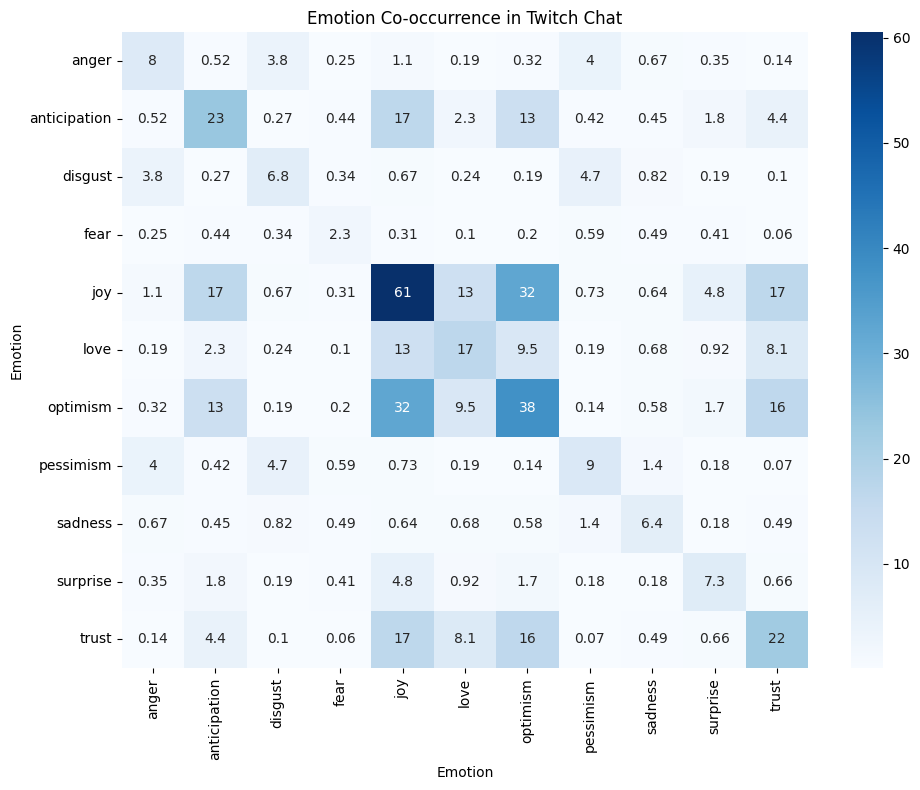

In [ ]:
# co-occurence of emotions

import seaborn as sns
import matplotlib.pyplot as plt

emotions = df[emotion_cols].astype(int)

co_occ_counts = emotions.T @ emotions

co_occ_norm = co_occ_counts / len(df) * 100
co_occ_norm = co_occ_norm.round(2)

print(co_occ_norm)

plt.figure(figsize=(10,8))

sns.heatmap(
    co_occ_norm,
    annot=True,        # show numbers in cell
    cmap="Blues"      # color scheme
)

plt.title("Emotion Co-occurrence in Twitch Chat")
plt.xlabel("Emotion")
plt.ylabel("Emotion")

plt.tight_layout()
plt.savefig(f"emotion_heatmap_all.png", dpi=300)
plt.show()

In [ ]:
# emotion association strenght
jaccard = {}

for e1, e2 in itertools.combinations(emotion_cols, 2):

    intersection = (df[e1] & df[e2]).sum()
    union = (df[e1] | df[e2]).sum()

    jaccard[(e1,e2)] = intersection / union

sorted(jaccard.items(), key=lambda x: x[1], reverse=True)[:10]

[(('joy', 'optimism'), 0.49077432581611735),
 (('disgust', 'pessimism'), 0.42213883677298314),
 (('optimism', 'trust'), 0.37366294271452344),
 (('anger', 'disgust'), 0.33866415804327377),
 (('anger', 'pessimism'), 0.3126510878323932),
 (('anticipation', 'optimism'), 0.2801649305555556),
 (('love', 'trust'), 0.26184873949579834),
 (('joy', 'trust'), 0.2543818095689247),
 (('anticipation', 'joy'), 0.24887718754839708),
 (('love', 'optimism'), 0.20877354157096922)]

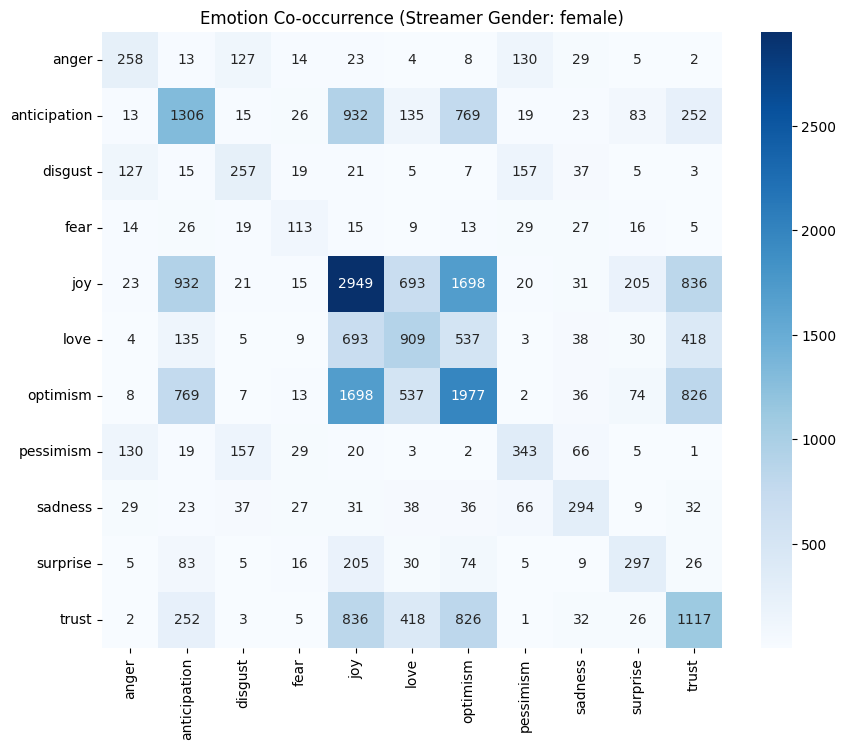

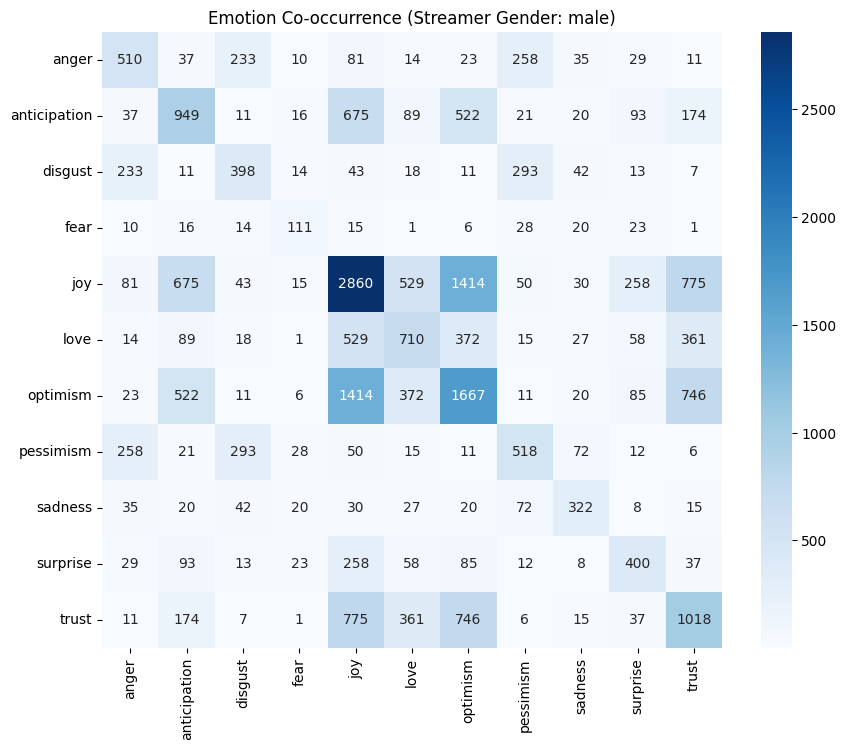

In [ ]:
# emotion association for gender
for g in df["gender"].unique():

    subset = df[df["gender"] == g]

    co_matrix = subset[emotion_cols].astype(int).T.dot(
        subset[emotion_cols].astype(int)
    )

    plt.figure(figsize=(10,8))

    sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Emotion Co-occurrence (Streamer Gender: {g})")

    plt.show()

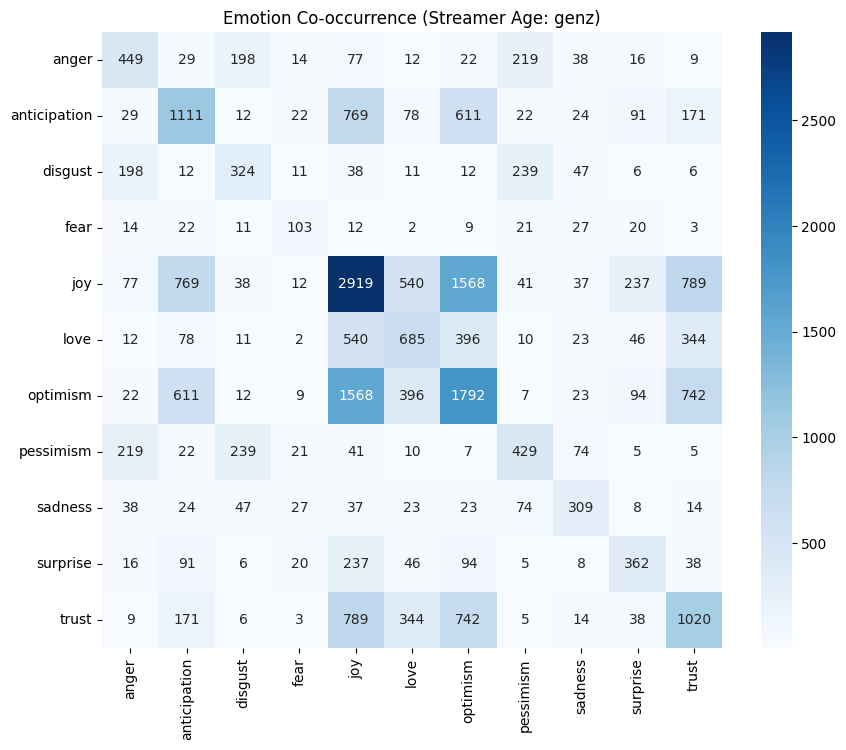

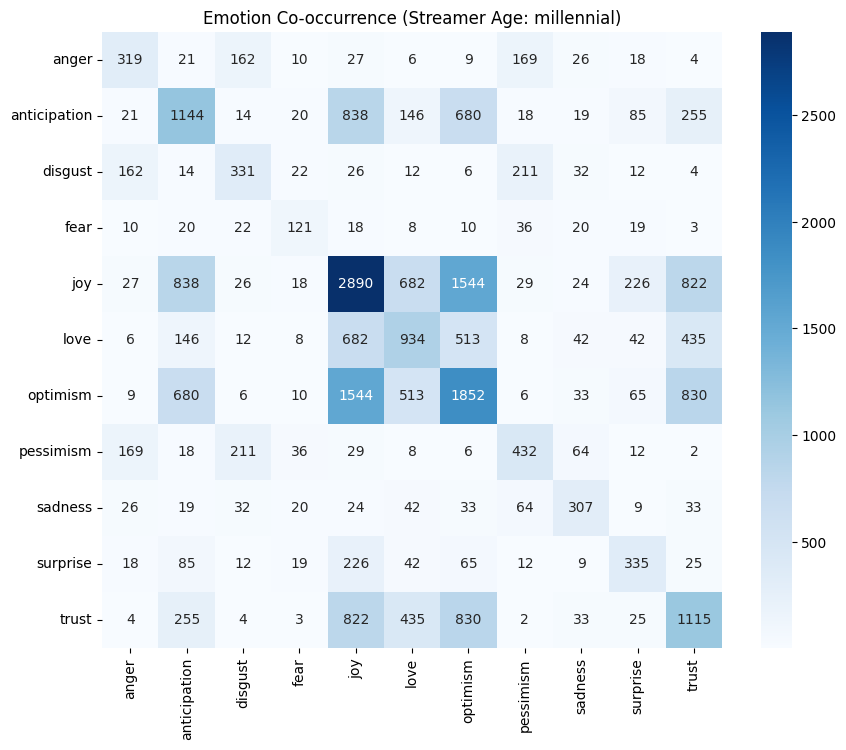

In [ ]:
# emotion association for age
for g in df["age"].unique():

    subset = df[df["age"] == g]

    co_matrix = subset[emotion_cols].astype(int).T.dot(
        subset[emotion_cols].astype(int)
    )

    plt.figure(figsize=(10,8))

    sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Emotion Co-occurrence (Streamer Age: {g})")

    plt.show()

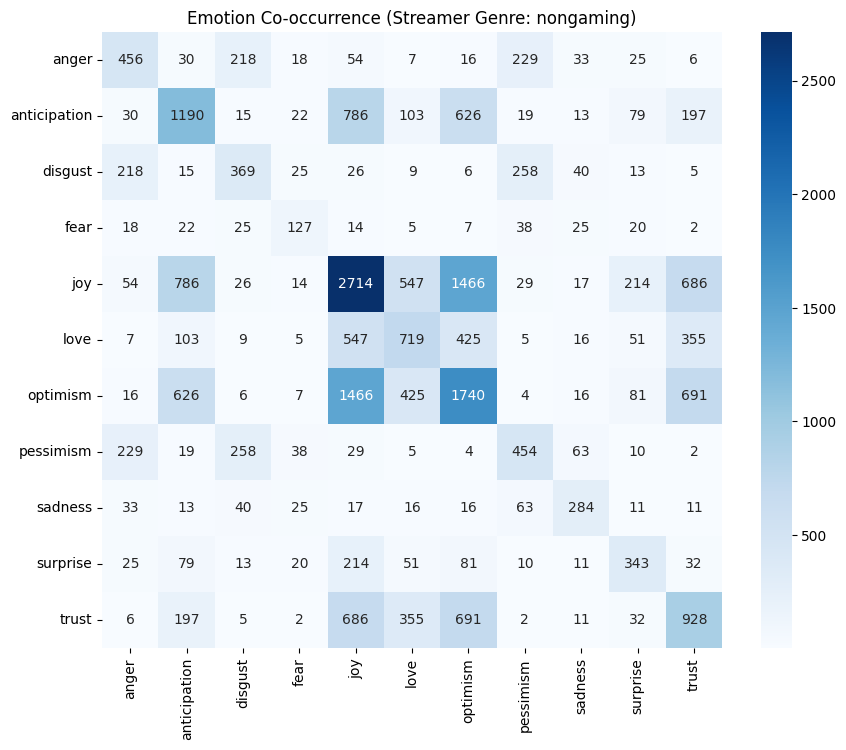

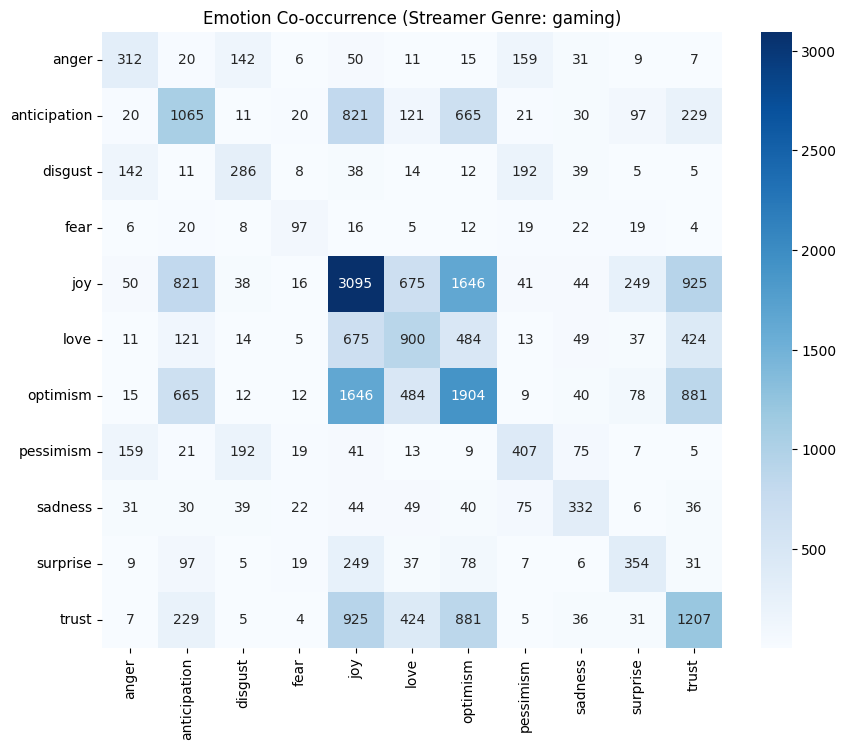

In [ ]:
# emotion association for genre
for g in df["genre"].unique():

    subset = df[df["genre"] == g]

    co_matrix = subset[emotion_cols].astype(int).T.dot(
        subset[emotion_cols].astype(int)
    )

    plt.figure(figsize=(10,8))

    sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Emotion Co-occurrence (Streamer Genre: {g})")

    plt.show()

In [ ]:
# emotion association per group and interaction, function

co_occ_by_group = {}

for name, subset in df.groupby(["gender", "genre", "age"]):

    emotions = subset[emotion_cols].astype(int)
    co_occ = emotions.T @ emotions
    co_occ_norm = co_occ / len(subset)
    co_occ_norm = co_occ_norm * 100
    co_occ_norm = co_occ_norm.round(2)

    co_occ_by_group[name] = co_occ_norm  # norm for percentage rater than counts

In [ ]:
# example
co_occ_by_group[('female','gaming','genz')]

,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
anger,5.58,0.25,2.17,0.08,0.75,0.00,0.33,2.58,0.42,0.00,0.08
anticipation,0.25,26.25,0.33,0.42,21.83,2.33,19.08,0.58,0.50,2.08,6.33
disgust,2.17,0.33,4.42,0.25,0.50,0.00,0.25,2.67,0.92,0.17,0.08
fear,0.08,0.42,0.25,1.92,0.50,0.08,0.50,0.50,0.42,0.42,0.08
joy,0.75,21.83,0.50,0.50,66.58,12.83,40.67,0.25,0.25,4.58,21.08
love,0.00,2.33,0.00,0.08,12.83,16.42,9.92,0.08,0.33,0.33,8.58
optimism,0.33,19.08,0.25,0.50,40.67,9.92,44.92,0.08,0.25,1.58,19.42
pessimism,2.58,0.58,2.67,0.50,0.25,0.08,0.08,6.83,1.33,0.08,0.08
sadness,0.42,0.50,0.92,0.42,0.25,0.33,0.25,1.33,5.25,0.08,0.33
surprise,0.00,2.08,0.17,0.42,4.58,0.33,1.58,0.08,0.08,6.58,0.50


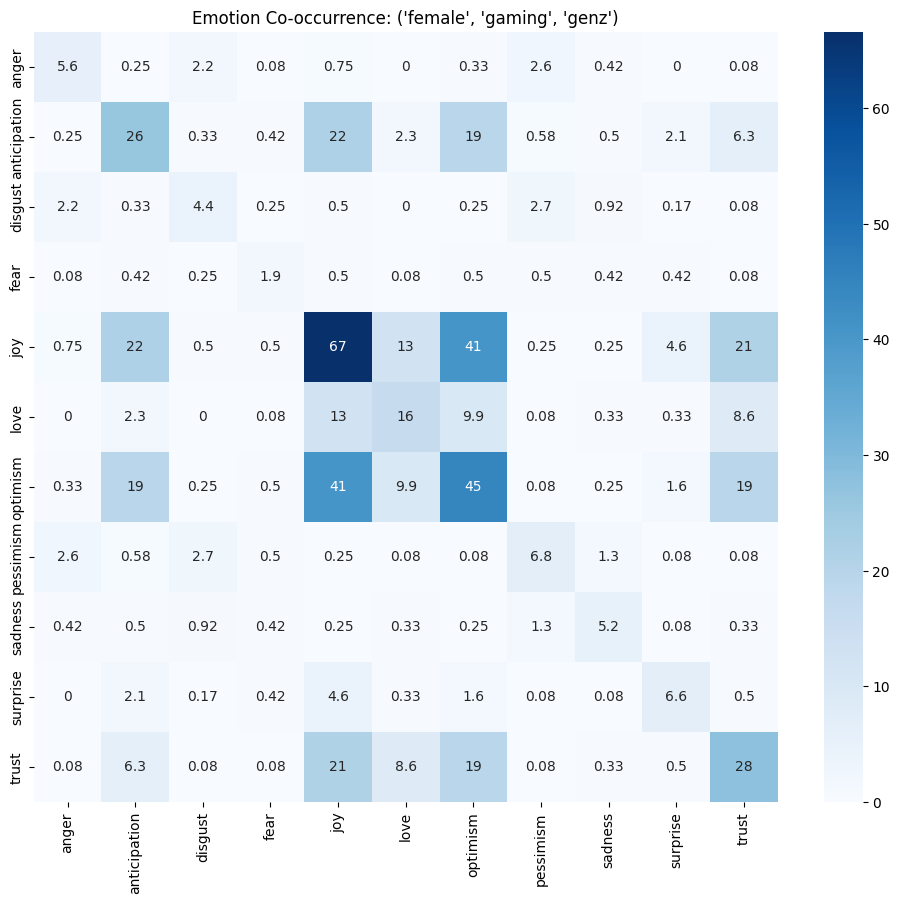

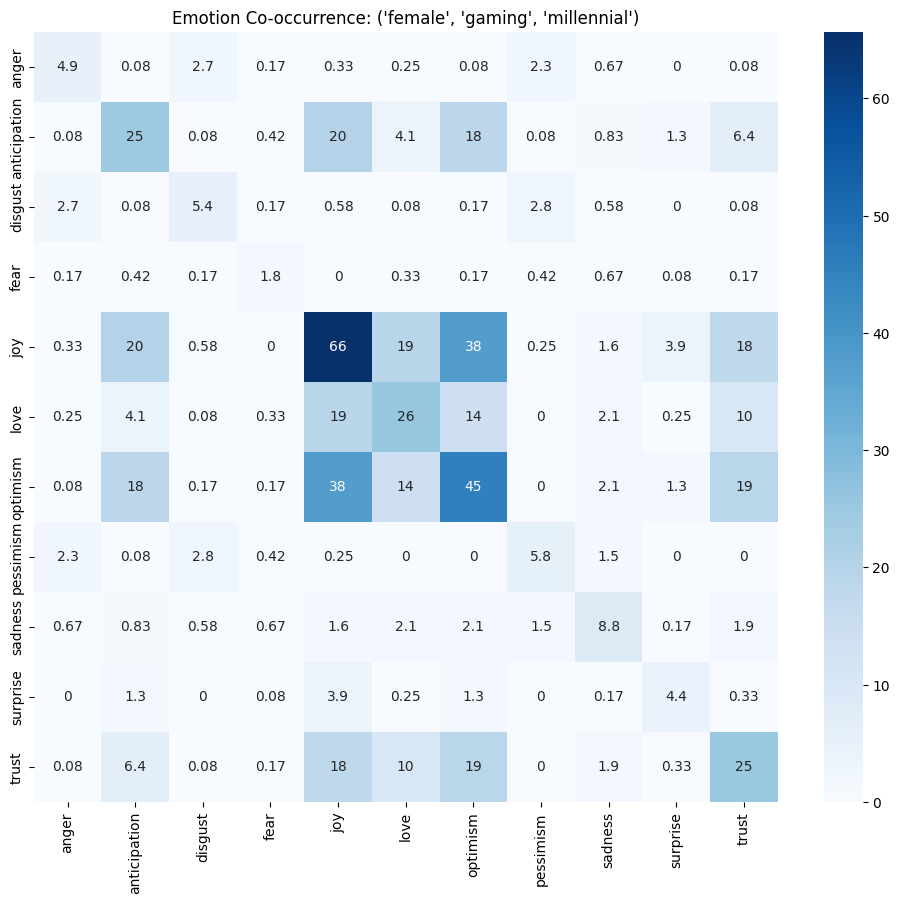

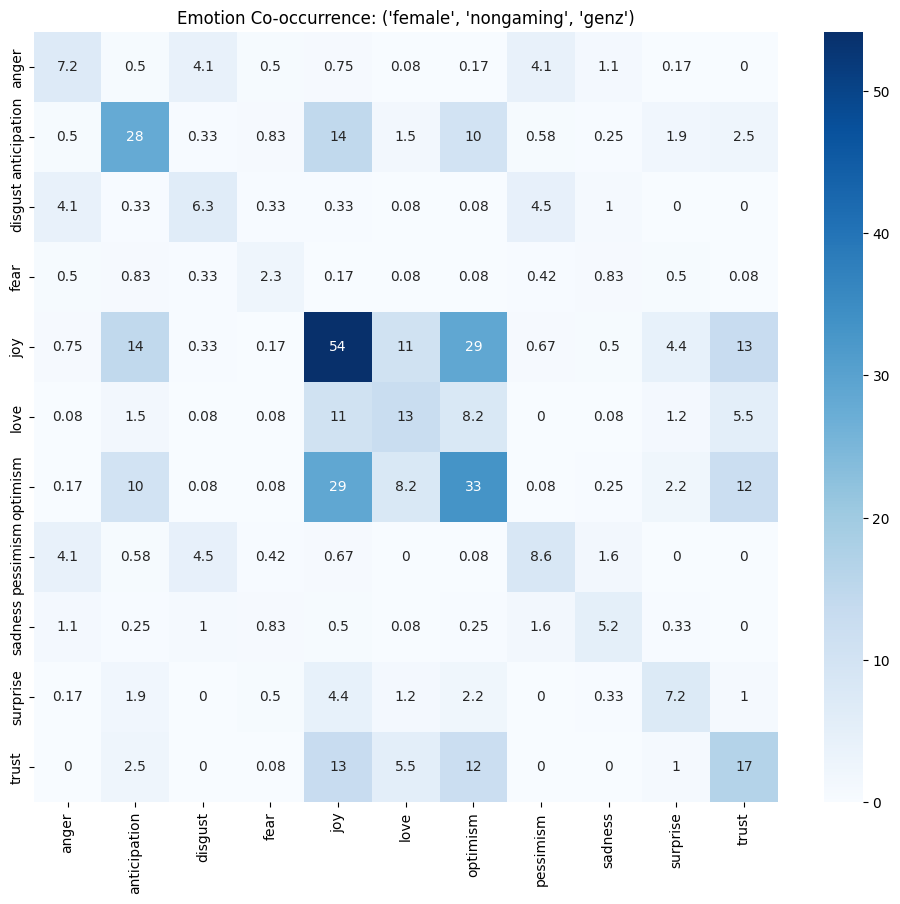

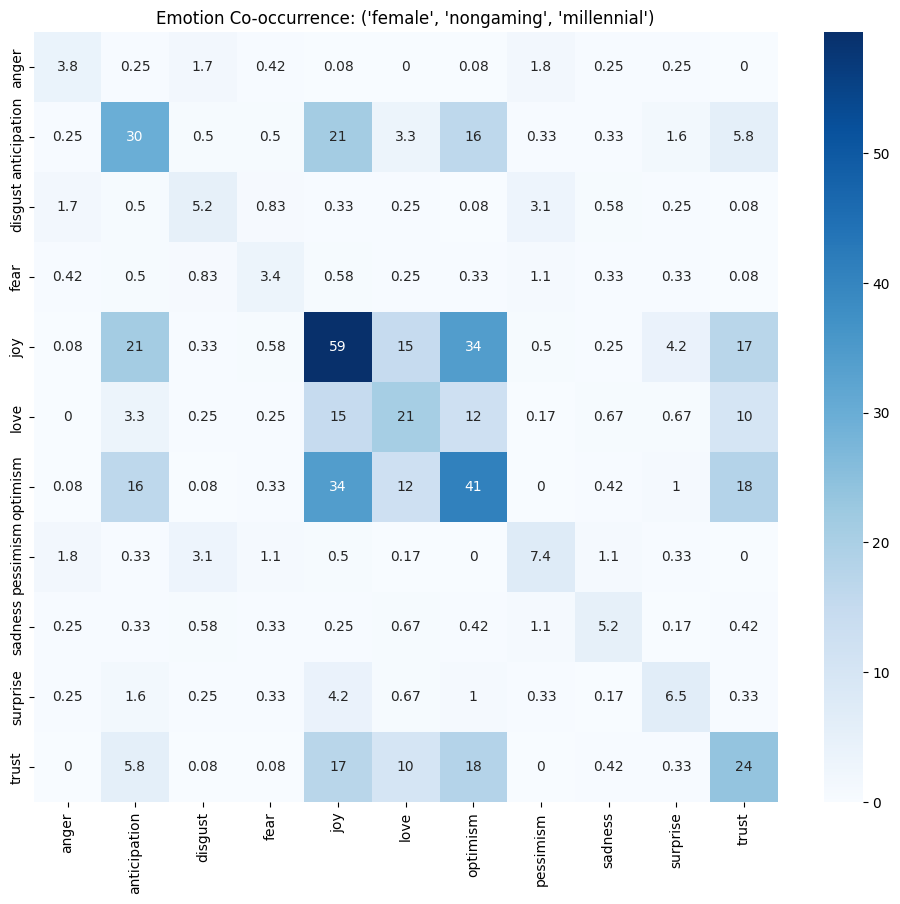

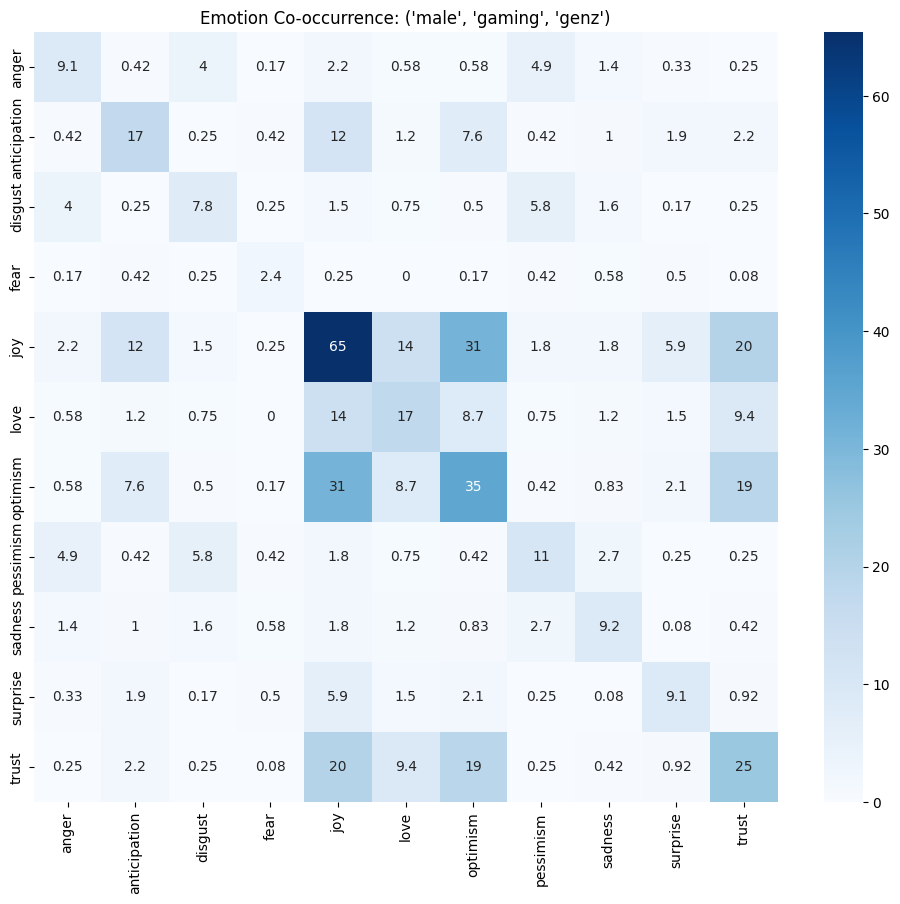

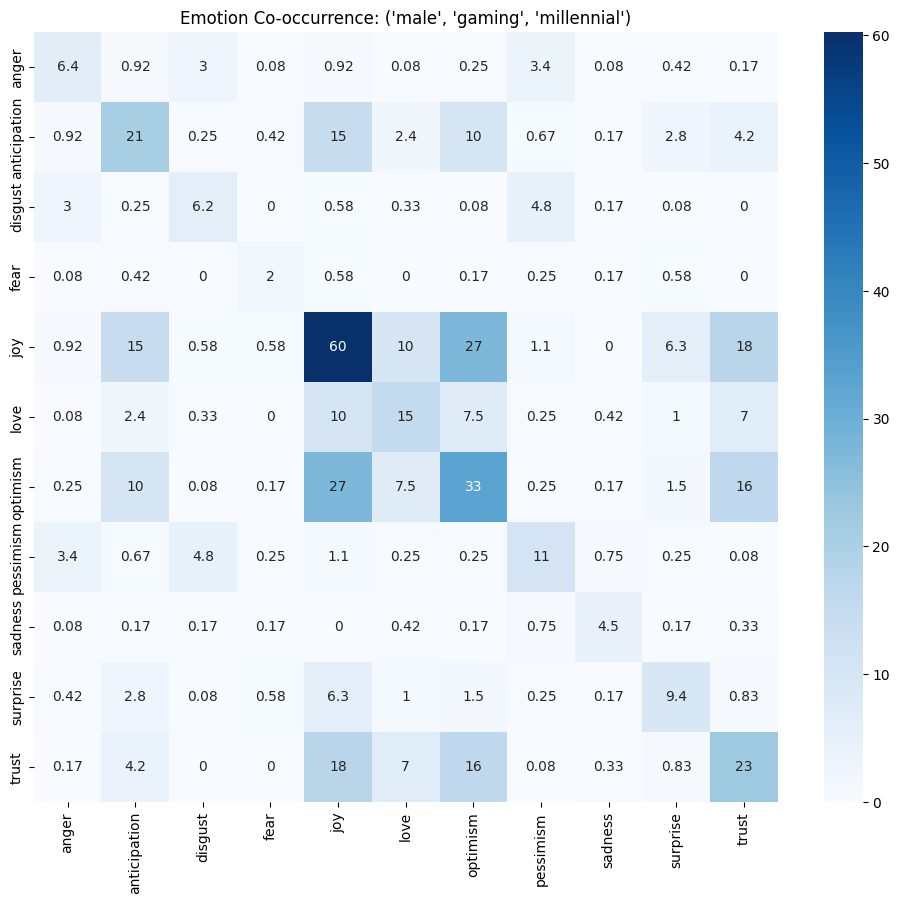

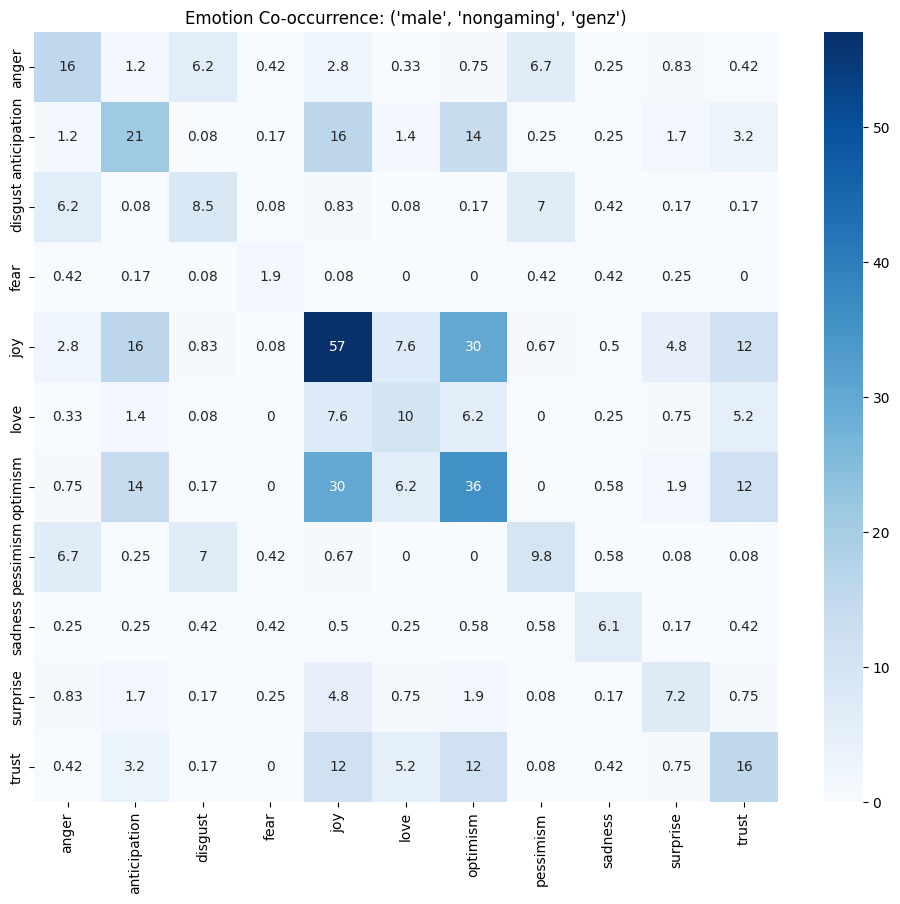

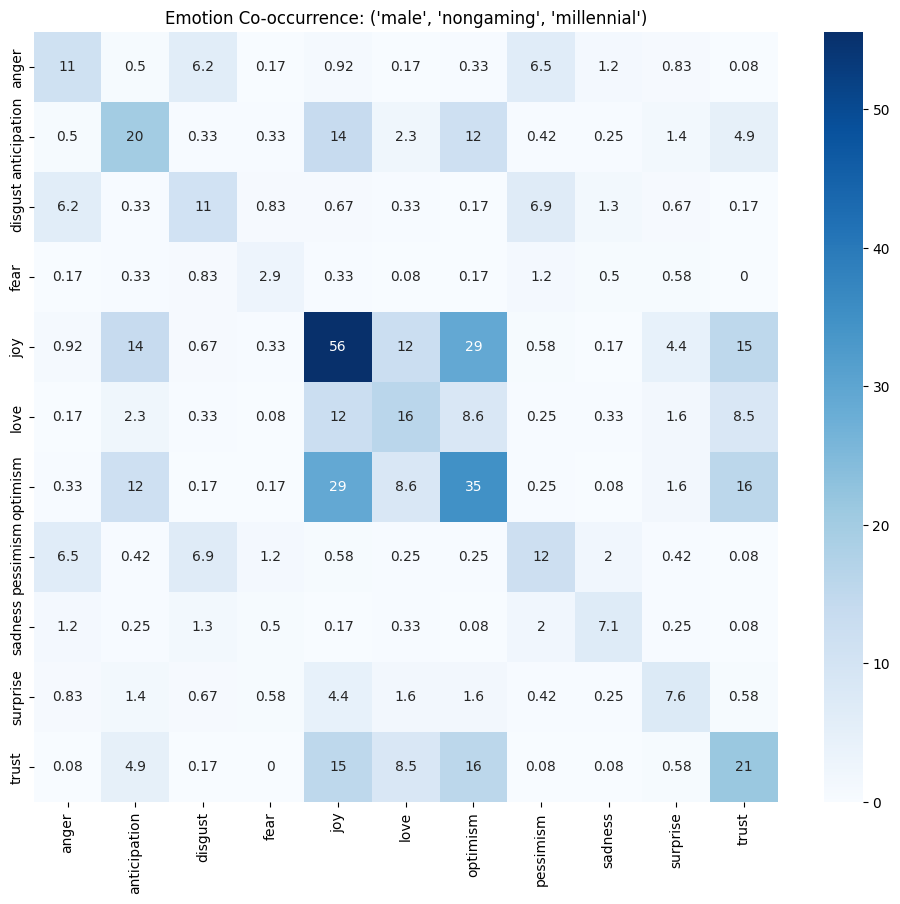

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

for group, matrix in co_occ_by_group.items():

    plt.figure(figsize=(12,10))
    sns.heatmap(matrix, annot=True, cmap="Blues")

    plt.title(f"Emotion Co-occurrence: {group}")
    group_str = "_".join([str(x) for x in group])
    plt.savefig(f"emotion_heatmap_{group_str}.png", dpi=300)
    plt.show()